# Stochastic Harmonic Oscillator

**Author:** Alberto Reyes Castro  
**Original context:** Computational Physics coursework  
**Public version:** English translation and cleaned formatting while preserving the original GIF and plotting style.

This notebook studies a simple harmonic oscillator when stochastic variation is introduced into the initial position.

## Coursework Task

Modify the second-order ODE problem from the previous practice so that the initial conditions or another parameter of the corresponding differential equation becomes stochastic. Then, analyse the behaviour of the system.

The original instruction allows the use of SciPy's ODE solvers directly. In this notebook, the equation is solved using `solve_ivp` with the `RK45` method.

## Physical Problem: Simple Harmonic Oscillator

The selected physical problem is the simple harmonic oscillator. This motion occurs when an object moves along one axis and is subject to a restoring force proportional to its displacement from the equilibrium position.

The equation of motion is:

$$
m\frac{d^2x}{dt^2} = -kx
$$

where:

- $m$ is the mass,
- $k$ is the spring constant,
- $x(t)$ is the position as a function of time.

![Simple_harmonic_oscillator[1].gif](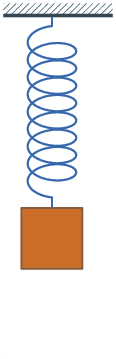)

To solve this second-order ODE numerically, it is rewritten as a system of two first-order equations. Defining:

$$
v = \frac{dx}{dt},
$$

we obtain:

$$
\frac{dx}{dt}=v
$$

and:

$$
\frac{dv}{dt}=-\frac{k}{m}x.
$$

The exact deterministic solution has the general form:

$$
x(t)=A\cos\left(\sqrt{\frac{k}{m}}t+\phi\right).
$$

In the deterministic case, $A$ and $\phi$ are fixed by the initial conditions. In this stochastic version, the initial position $x_0$ is randomly perturbed.

## Percentile Analysis

Percentiles are used to summarise the distribution of the stochastic trajectories over time.

The 25th percentile indicates the value below which 25% of the simulated values fall. The 50th percentile is the median, and the 75th percentile indicates the value below which 75% of the simulated values fall.

In this notebook, the 25th, 50th and 75th percentiles are computed for both position and velocity.

## Implementation

The code below keeps the original coursework idea and visual structure:

- individual stochastic solutions are shown on the left,
- percentile curves for position and velocity are shown on the right,
- the same GIF and the same type of plot are preserved.

The stochastic component is applied to the initial position $x_0$, while the mass $m$ and spring constant $k$ are kept fixed. This makes the trajectories smooth and faithful to the original coursework plot.

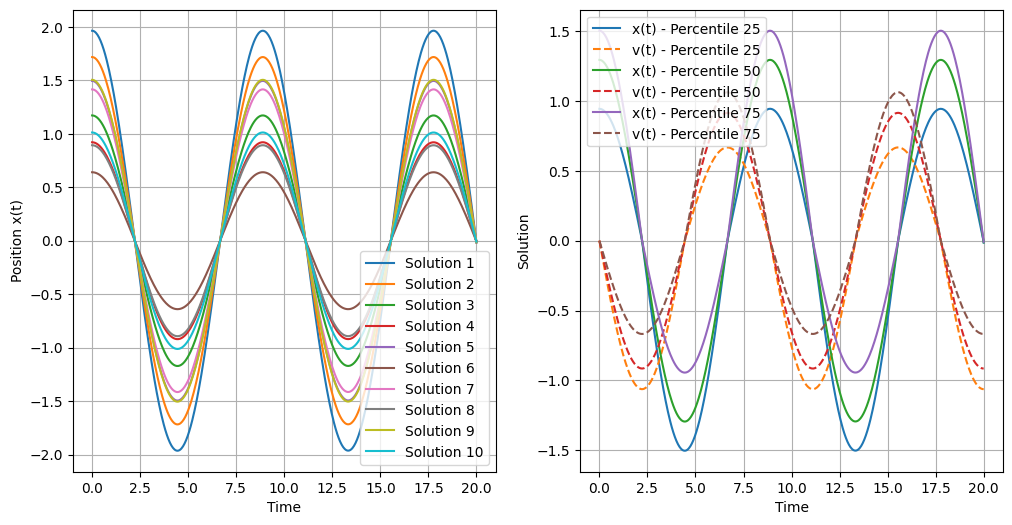

In [1]:
# Import the required modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System parameters: mass m and spring constant k
m = 1.0
k = 0.5

# First-order system equivalent to the harmonic oscillator equation
def harmonic_oscillator_system(t, y):
    x, v = y
    dxdt = v
    dvdt = (-k / m) * x
    return [dxdt, dvdt]


# Initial conditions: position x0 and velocity v0
x0 = 1.0
v0 = 0.0

# Time interval for solving the ODE
t_interval = (0, 20)
t_eval = np.linspace(t_interval[0], t_interval[1], 500)

# Stochastic component using a normal distribution
mu = 0.0
sigma = 0.5

# Number of individual solutions to display
n_solutions = 10

# Percentiles to compute
percentiles = [25, 50, 75]

# Matrices to store position and velocity results
results_x = np.zeros((n_solutions, len(t_eval)))
results_v = np.zeros((n_solutions, len(t_eval)))

# Create figure and subplots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Compute individual stochastic solutions
for i in range(n_solutions):
    x0_stochastic = x0 + np.random.normal(mu, sigma)

    solution = solve_ivp(
        harmonic_oscillator_system,
        t_interval,
        [x0_stochastic, v0],
        method="RK45",
        t_eval=t_eval,
    )

    plt.plot(solution.t, solution.y[0], label=f"Solution {i + 1}")

    results_x[i] = solution.y[0]
    results_v[i] = solution.y[1]

# Labels and legend for the individual solutions plot
plt.xlabel("Time")
plt.ylabel("Position x(t)")
plt.legend()
plt.grid(True)

# Compute percentiles
x_percentiles = np.percentile(results_x, percentiles, axis=0)
v_percentiles = np.percentile(results_v, percentiles, axis=0)

# Percentile plot
plt.subplot(1, 2, 2)

for i, p in enumerate(percentiles):
    plt.plot(solution.t, x_percentiles[i], label=f"x(t) - Percentile {p}")
    plt.plot(solution.t, v_percentiles[i], label=f"v(t) - Percentile {p}", linestyle="--")

# Labels and legend for the percentile plot
plt.xlabel("Time")
plt.ylabel("Solution")
plt.legend()
plt.grid(True)

# Display both plots
plt.show()

## Analysis of the Stochastic Behaviour

The left-hand plot shows the variability of the harmonic oscillator trajectories after introducing stochastic variation in the initial position.

Each curve corresponds to a different realisation of the system. Since the spring constant is fixed, all solutions have the same oscillation frequency, but different amplitudes.

The right-hand plot summarises the ensemble of stochastic trajectories using percentiles. The 25th, 50th and 75th percentile curves describe how the distribution of position and velocity evolves over time.

This representation is useful because it provides a compact statistical description of the stochastic behaviour without plotting only one deterministic trajectory.

## Choice of Random Distribution

A normal distribution is used to model the stochastic perturbation in the initial position.

The distribution is controlled by two parameters:

- the mean $\mu$,
- the standard deviation $\sigma$.

In this implementation, $\mu=0$ and $\sigma=0.5$. This means that the stochastic perturbations are centred around the deterministic initial position. The mass and spring constant are kept fixed.

## Conclusion

This practice shows how stochastic variation in the initial position can modify the behaviour of a second-order dynamical system.

The simple harmonic oscillator remains a useful baseline model, but the introduction of random initial positions produces a family of possible trajectories rather than a single deterministic solution.

The percentile curves provide a compact way to analyse this family of solutions and to describe the variability of the system over time.